# CIFAR-10 — Dense baseline + CNN

Cleaned and extended version of the original CIFAR-10 notebook.

The structure deliberately follows the Fashion-MNIST notebook so the two exercises can be compared.

CIFAR-10 is more difficult than Fashion-MNIST:
- images are 32×32 rather than 28×28;
- images have 3 RGB channels rather than 1 grayscale channel;
- the 10 classes contain more visual variation.

Workflow:
1. load and verify data once;
2. create fixed train / validation / test sets;
3. inspect images and RGB structure;
4. train a Dense baseline;
5. train a CNN baseline;
6. check overfitting;
7. optionally test Dropout + data augmentation;
8. compare test performance and inspect errors.


In [1]:
# `os` lets us configure the Keras backend before importing Keras.
import os

# Use PyTorch as the backend for Keras on the current deep-learning environment.
os.environ["KERAS_BACKEND"] = "torch"

# NumPy handles multidimensional numerical arrays.
import numpy as np

# Matplotlib displays images and training curves.
import matplotlib.pyplot as plt

# Seaborn is used for the confusion-matrix heatmap.
import seaborn as sns

# Keras is the high-level deep-learning framework.
import keras

# Sequential builds a model as an ordered stack of layers.
# Model is used later to expose an intermediate CNN layer.
from keras.models import Sequential, Model

# Input defines the shape of one input example.
# Rescaling converts RGB pixel values from 0–255 to 0–1.
# Flatten converts a multidimensional tensor into one vector.
# Dense is a fully connected layer.
# Conv2D learns spatial filters from images.
# MaxPooling2D reduces spatial dimensions.
# Dropout is an optional regularization technique.
# RandomFlip/Translation/Rotation/Zoom are optional data-augmentation layers.
from keras.layers import (
    Input,
    Rescaling,
    Flatten,
    Dense,
    Conv2D,
    MaxPooling2D,
    Dropout,
    RandomFlip,
    RandomTranslation,
    RandomRotation,
    RandomZoom,
    RandomCrop,
    RandomContrast,
    RandomBrightness,
    RandomShear,

)

# Adam updates the network weights using gradients.
from keras.optimizers import Adam

# Sparse categorical cross-entropy is appropriate for integer class labels 0–9.
from keras.losses import SparseCategoricalCrossentropy

# CIFAR-10 provides 32×32 RGB images in 10 classes.
from keras.datasets import cifar10

# This creates the validation subset from the original training data.
from sklearn.model_selection import train_test_split

# These functions provide detailed classification diagnostics.
from sklearn.metrics import classification_report, confusion_matrix

# Verify the environment before training.
print("Keras version:", keras.__version__)
print("Keras backend:", keras.backend.backend())


Keras version: 3.15.1
Keras backend: torch


## 1. Load CIFAR-10 once

The original file called `cifar10.load_data()` twice. Only one call is needed.

CIFAR-10 provides:
- 50,000 original training images;
- 10,000 untouched test images.

We split the original 50,000 into:
- 40,000 training;
- 10,000 validation.

The official 10,000 test images remain untouched until final evaluation.


In [2]:
# Load the dataset exactly once.
# `_full` makes it clear that these are the original 50,000 training-side images.
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 labels arrive with shape (N, 1).
# Convert them to simple one-dimensional arrays: (N,).
y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

# Split the original 50,000 images into 80% training and 20% validation.
# `stratify` keeps approximately equal class proportions in both subsets.
# `random_state=1` makes the split reproducible.
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.20,
    random_state=1,
    stratify=y_train_full,
)

# Display all shapes before any model is trained.
print("Train:     ", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:      ", x_test.shape, y_test.shape)

# Stop immediately if the data structure is not the one expected.
assert x_train.shape == (40000, 32, 32, 3)
assert x_val.shape == (10000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)

# CIFAR-10 uses RGB pixel intensities from 0 to 255.
print("Pixel range:", x_train.min(), "to", x_train.max())
print("Data type:", x_train.dtype)


Train:      (40000, 32, 32, 3) (40000,)
Validation: (10000, 32, 32, 3) (10000,)
Test:       (10000, 32, 32, 3) (10000,)
Pixel range: 0 to 255
Data type: uint8


In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())
print(
    "GPU:",
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)
print("Keras backend:", keras.backend.backend())

CUDA available: True
GPU: NVIDIA RTX PRO 4000 Blackwell
Keras backend: torch


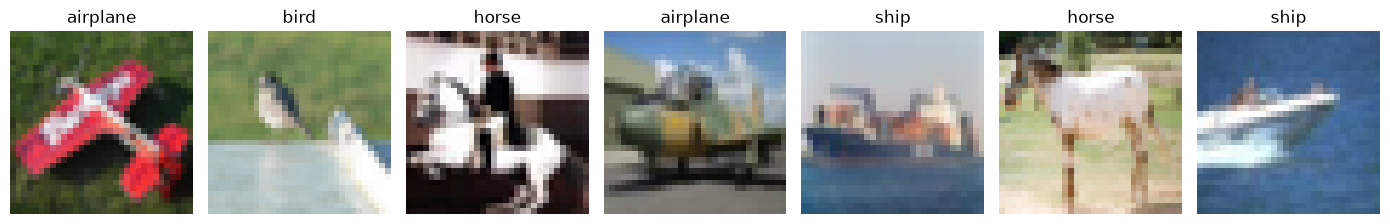

In [4]:
# Human-readable class names corresponding to labels 0–9.
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

# Display seven reproducible random training examples.
rng = np.random.default_rng(42)
plt.figure(figsize=(14, 3))

for position in range(7):
    # Select one random image.
    index = rng.integers(0, len(x_train))

    # Create one place in a row of seven images.
    plt.subplot(1, 7, position + 1)

    # CIFAR-10 is already RGB, so no grayscale colour map is needed.
    plt.imshow(x_train[index])

    # Translate the numeric label into its class name.
    plt.title(class_names[y_train[index]])

    # Hide pixel-coordinate axes.
    plt.axis("off")

plt.tight_layout()
plt.show()


## 2. Understand the CIFAR-10 tensor

One image has shape `(32, 32, 3)`:

- 32 = height;
- 32 = width;
- 3 = RGB channels.

Unlike Fashion-MNIST, we do **not** need `Reshape((32, 32, 1))`, because CIFAR-10 already contains the channel dimension.


One image shape: (32, 32, 3)
First pixel RGB: [176 165 136]


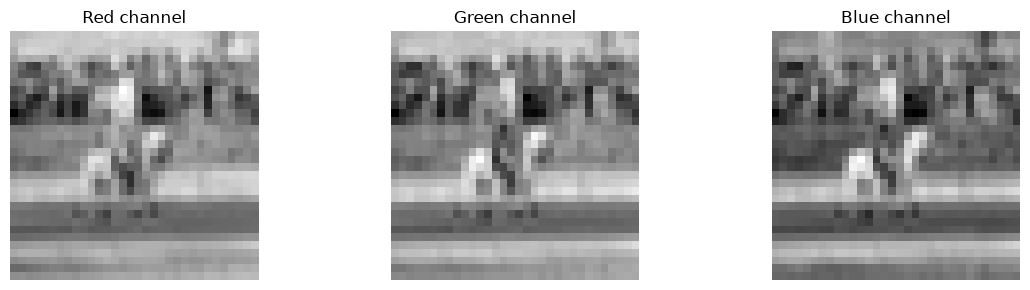

In [5]:
# Select one image to inspect numerically.
sample = x_train[0]

# Show its tensor shape.
print("One image shape:", sample.shape)

# Show the RGB values of the first pixel.
print("First pixel RGB:", sample[0, 0])

# Show each channel separately.
plt.figure(figsize=(12, 3))

# Red channel.
plt.subplot(1, 3, 1)
plt.imshow(sample[:, :, 0], cmap="gray")
plt.title("Red channel")
plt.axis("off")

# Green channel.
plt.subplot(1, 3, 2)
plt.imshow(sample[:, :, 1], cmap="gray")
plt.title("Green channel")
plt.axis("off")

# Blue channel.
plt.subplot(1, 3, 3)
plt.imshow(sample[:, :, 2], cmap="gray")
plt.title("Blue channel")
plt.axis("off")

plt.tight_layout()
plt.show()


## 3. Dense baseline

This intentionally ignores the 2D spatial structure.

`32 × 32 × 3 = 3072` input values are flattened into one vector.

The Dense model gives us a baseline. The CNN should be better suited to image structure.


In [6]:
# Build a fresh Dense baseline.
def build_dense_model() -> Sequential:
    model = Sequential([
        # One input image is 32×32 with three RGB channels.
        Input(shape=(32, 32, 3)),

        # Normalize pixel intensities: 0–255 becomes 0–1.
        Rescaling(1.0 / 255),

        # Convert 32×32×3 = 3072 values into one vector.
        Flatten(),

        # Learn a first set of 128 features.
        Dense(512, activation="relu"),

        # Learn a first set of 128 features.
        Dense(128, activation="relu"),

        # Learn another set of 128 features.
        Dense(64, activation="relu"),

        # Produce probabilities for the 10 classes.
        Dense(10, activation="softmax"),
    ])

    # Configure learning.
    model.compile(
        optimizer=Adam(),
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    return model


# Create the Dense model.
dense_model = build_dense_model()

# Inspect its layers and parameter counts.
dense_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,647,946 (6.29 MB)

 Trainable params: 1,647,946 (6.29 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the Dense model and retain its learning history.
dense_history = dense_model.fit(
    x_train,
    y_train,

    # Number of images processed before each weight update.
    batch_size=256,

    # Maximum number of complete passes through the training set.
    epochs=20,

    # Validation data monitors generalization but does not update weights.
    validation_data=(x_val, y_val),

    verbose=1,
)


Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2750 - loss: 2.0056 - val_accuracy: 0.3156 - val_loss: 1.9183
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3571 - loss: 1.7960 - val_accuracy: 0.3832 - val_loss: 1.7444
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3978 - loss: 1.6907 - val_accuracy: 0.3863 - val_loss: 1.7210
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4149 - loss: 1.6420 - val_accuracy: 0.4009 - val_loss: 1.6812
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4354 - loss: 1.5879 - val_accuracy: 0.4342 - val_loss: 1.5994
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4503 - loss: 1.5458 - val_accuracy: 0.4400 - val_loss: 1.5921
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4629 - loss: 1.5133 - val_accuracy: 0.4289 - val_loss: 1.5947
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4727 - loss: 1.4749 - val_accuracy: 0.

## 4. Reusable fitting / overfitting check

Watch both accuracy and loss.

Potential overfitting:
- training accuracy continues rising;
- validation accuracy stops rising or falls;
- training loss continues falling;
- validation loss starts rising.


Best validation-loss epoch: 20
Final training accuracy:    0.5602
Final validation accuracy:  0.5016
Final training loss:        1.2390
Final validation loss:      1.4120


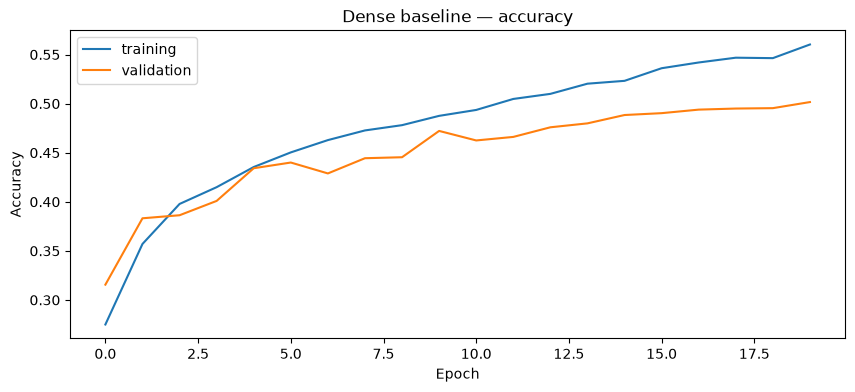

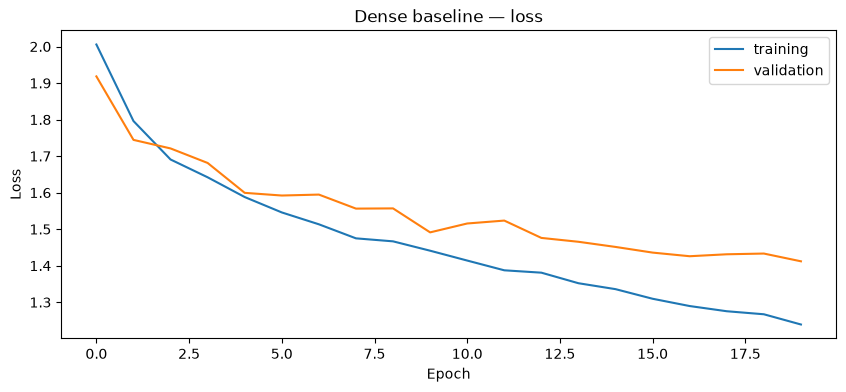

In [8]:
# Use the same diagnostic function for every model.
def plot_training_history(history, title: str):
    logs = history.history

    # Find the epoch at which validation loss was lowest.
    best_epoch = int(np.argmin(logs["val_loss"])) + 1

    print("Best validation-loss epoch:", best_epoch)
    print("Final training accuracy:   ", f'{logs["accuracy"][-1]:.4f}')
    print("Final validation accuracy: ", f'{logs["val_accuracy"][-1]:.4f}')
    print("Final training loss:       ", f'{logs["loss"][-1]:.4f}')
    print("Final validation loss:     ", f'{logs["val_loss"][-1]:.4f}')

    # Accuracy graph.
    plt.figure(figsize=(10, 4))
    plt.plot(logs["accuracy"], label="training")
    plt.plot(logs["val_accuracy"], label="validation")
    plt.title(f"{title} — accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss graph.
    plt.figure(figsize=(10, 4))
    plt.plot(logs["loss"], label="training")
    plt.plot(logs["val_loss"], label="validation")
    plt.title(f"{title} — loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


# Diagnose the Dense model.
plot_training_history(dense_history, "Dense baseline")


/tmp/ipykernel_102971/3538749430.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(dense_model.layers[-1].weights[0]).ravel()


<Axes: ylabel='Density'>

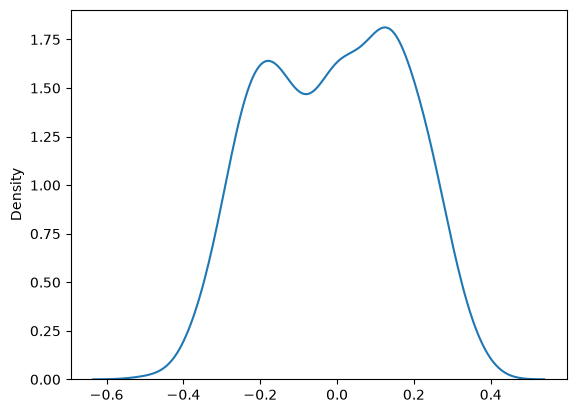

In [13]:
sns.kdeplot(
    np.array(dense_model.layers[-1].weights[0]).ravel()
)

In [14]:
# Evaluate the Dense model on the untouched official CIFAR-10 test set.
dense_test_loss, dense_test_accuracy = dense_model.evaluate(
    x_test,
    y_test,
    verbose=0,
)

# These are the final independent Dense baseline measurements.
print("Dense test loss:", round(dense_test_loss, 4))
print("Dense test accuracy:", round(dense_test_accuracy, 4))


Dense test loss: 1.3884
Dense test accuracy: 0.5094


## 5. CNN baseline

The CNN keeps the image's spatial structure and all three RGB channels.

The first convolution receives `(32, 32, 3)` directly.

We first train **without Dropout and without augmentation**. This gives a clean baseline before fine-tuning.


In [15]:
# Build either a clean CNN or, later, a regularized version.
def build_cnn_model(
    use_augmentation: bool = False,
    dropout_rate: float = 0.0,
) -> Sequential:

    # Layers common to all versions.
    layers = [
        # CIFAR-10 already has shape 32×32×3.
        Input(shape=(32, 32, 3)),

        # Convert RGB values from 0–255 to 0–1.
        Rescaling(1.0 / 255),
    ]

    # Add augmentation only when explicitly requested.
    if use_augmentation:
        layers.extend([
            # Horizontal flipping is usually class-preserving for CIFAR-10 objects.
            RandomFlip("horizontal"),

            # Shift the object slightly within the image.
            #RandomTranslation(height_factor=0.10, width_factor=0.10),

            # Apply a small random rotation.
            #RandomRotation(factor=0.05),

            # Apply a small random zoom.
            #RandomZoom(height_factor=0.10, width_factor=0.10),
        ])

    # CNN feature extraction.
    layers.extend([
        # 32 learned 3×3 filters; spatial size remains 32×32.
        Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),

        # Learn 32 further feature maps from the previous 32 channels.
        Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),

        # Reduce spatial dimensions: 32×32 → 16×16.
        MaxPooling2D(pool_size=(2, 2)),

        # Increase feature depth from 32 to 64.
        Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),

        # Learn more complex combinations of those features.
        Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),

        # Reduce spatial dimensions: 16×16 → 8×8.
        MaxPooling2D(pool_size=(2, 2)),

        # Increase feature depth again.
        Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),

        # Reduce spatial dimensions: 8×8 → 4×4.
        MaxPooling2D(pool_size=(2, 2)),

        # Convert 4×4×128 feature maps into one vector.
        Flatten(),

        # Combine extracted features for classification.
        Dense(128, activation="relu"),

        # Combine extracted features for classification.
        Dense(128, activation="relu"),
    ])

    # Add Dropout only for the regularized experiment.
    if dropout_rate > 0:
        layers.append(Dropout(dropout_rate))

    # Final 10-class probability output.
    layers.append(Dense(10, activation="softmax"))

    model = Sequential(layers)

    # Configure training.
    model.compile(
        optimizer=Adam(),
        loss=SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    return model


In [16]:
# Create the clean CNN baseline.
cnn = build_cnn_model(
    use_augmentation=False,
    dropout_rate=0.0,
)

# Inspect output shapes and trainable parameters before training.
cnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,498 (1.60 MB)

 Trainable params: 419,498 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3634 - loss: 1.7281 - val_accuracy: 0.4383 - val_loss: 1.6001
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5292 - loss: 1.3082 - val_accuracy: 0.5675 - val_loss: 1.2279
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6224 - loss: 1.0628 - val_accuracy: 0.6322 - val_loss: 1.0537
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6769 - loss: 0.9176 - val_accuracy: 0.6509 - val_loss: 0.9920
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7165 - loss: 0.8090 - val_accuracy: 0.6896 - val_loss: 0.8889
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7494 - loss: 0.7176 - val_accuracy: 0.7178 - val_loss: 0.8190
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7803 - loss: 0.6361 - val_accuracy: 0.7180 - val_loss: 0.8313
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8032 - loss: 0.5637 - val_accu

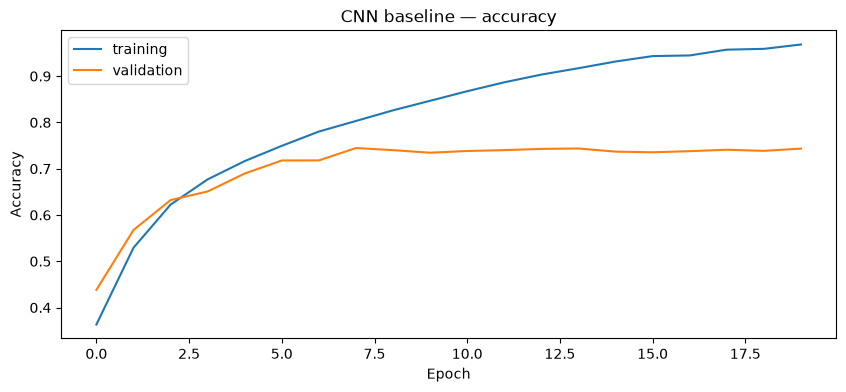

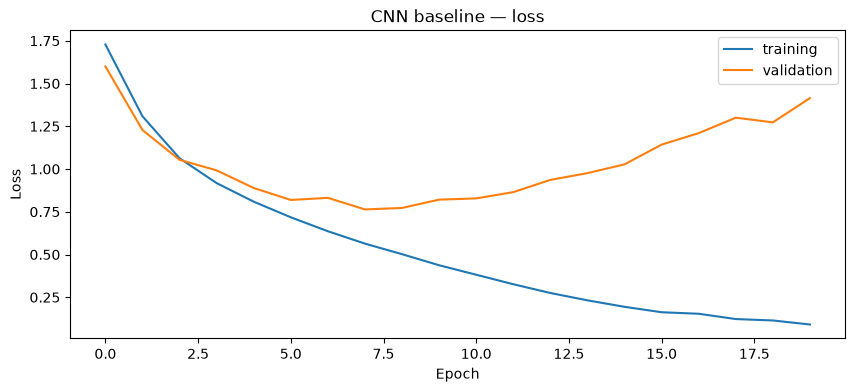

In [17]:
# Train the clean CNN baseline.
cnn_history = cnn.fit(
    x_train,
    y_train,
    batch_size=256,
    epochs=20,
    validation_data=(x_val, y_val),
    verbose=1,
)

# Check whether training and validation curves diverge.
plot_training_history(cnn_history, "CNN baseline")


/tmp/ipykernel_102971/129707683.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.kdeplot(np.array(cnn.layers[-1].weights[0]).ravel())


<Axes: ylabel='Density'>

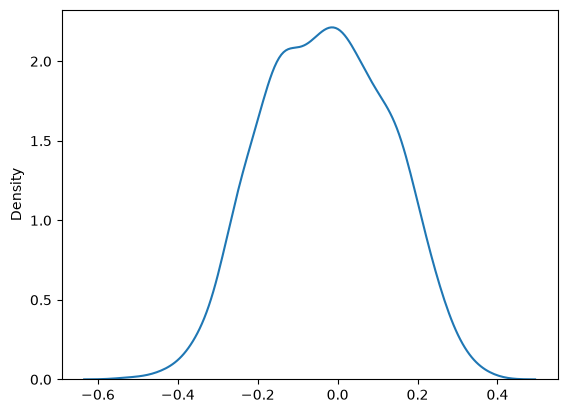

In [18]:
sns.kdeplot(np.array(cnn.layers[-1].weights[0]).ravel())

In [19]:
# Evaluate the CNN on the same untouched official test set.
cnn_test_loss, cnn_test_accuracy = cnn.evaluate(
    x_test,
    y_test,
    verbose=0,
)

print("CNN test loss:", round(cnn_test_loss, 4))
print("CNN test accuracy:", round(cnn_test_accuracy, 4))

# Direct comparison with the Dense baseline.
print()
print("Dense test accuracy:", round(dense_test_accuracy, 4))
print("CNN test accuracy:  ", round(cnn_test_accuracy, 4))


CNN test loss: 1.4218
CNN test accuracy: 0.7414

Dense test accuracy: 0.5094
CNN test accuracy:   0.7414


## 6. Optional fine-tuning: augmentation + Dropout

Do not treat this as automatically better.

First inspect the clean CNN. If it overfits, this is a controlled regularization experiment.

The architecture stays the same; the principal changes are:
- data augmentation;
- `Dropout(0.30)`.


In [20]:
# Build the regularized version of the same CNN.
cnn_tuned = build_cnn_model(
    use_augmentation=True,
    dropout_rate=0.30,
)

cnn_tuned.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,498 (1.60 MB)

 Trainable params: 419,498 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3141 - loss: 1.8407 - val_accuracy: 0.4282 - val_loss: 1.5788
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4797 - loss: 1.4179 - val_accuracy: 0.5256 - val_loss: 1.2981
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5677 - loss: 1.2084 - val_accuracy: 0.5776 - val_loss: 1.2059
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6332 - loss: 1.0426 - val_accuracy: 0.6447 - val_loss: 1.0116
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6744 - loss: 0.9200 - val_accuracy: 0.6696 - val_loss: 0.9439
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7046 - loss: 0.8452 - val_accuracy: 0.6932 - val_loss: 0.8781
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7338 - loss: 0.7706 - val_accuracy: 0.7044 - val_loss: 0.8340
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7490 - loss: 0.7199 - val_accu

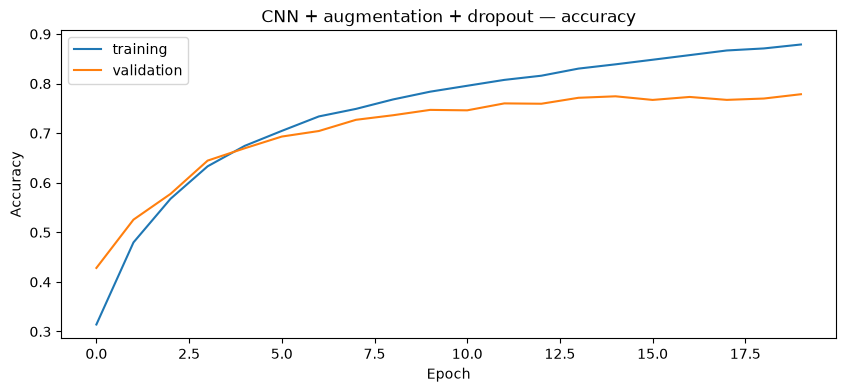

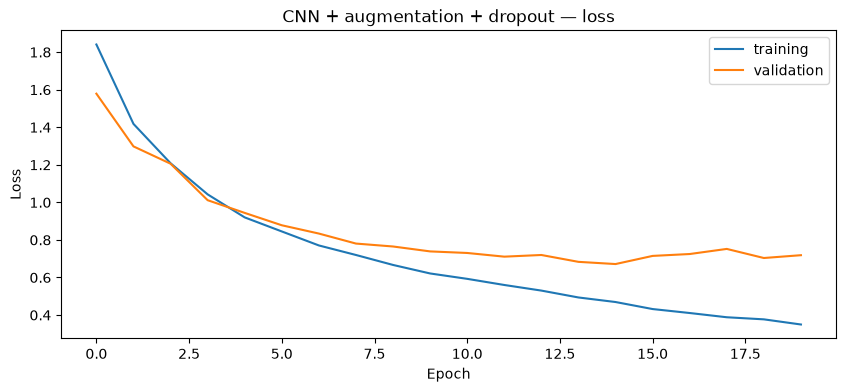

In [21]:
# Train using exactly the same train/validation split and batch size.
cnn_tuned_history = cnn_tuned.fit(
    x_train,
    y_train,
    batch_size=256,
    epochs=20,
    validation_data=(x_val, y_val),
    verbose=1,
)

# Inspect whether regularization improves validation behaviour.
plot_training_history(
    cnn_tuned_history,
    "CNN + augmentation + dropout",
)


/tmp/ipykernel_102971/3258952090.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.kdeplot(np.array(cnn_tuned.layers[-1].weights[0]).ravel())


<Axes: ylabel='Density'>

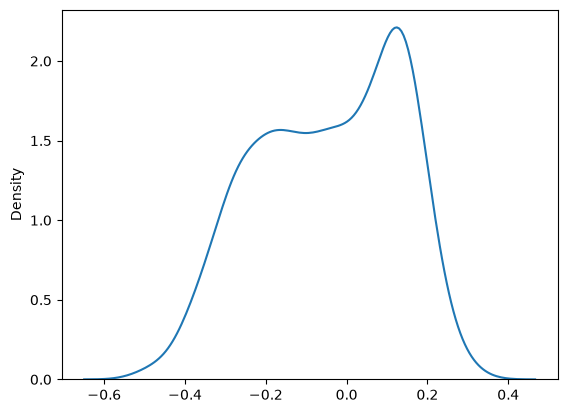

In [22]:
sns.kdeplot(np.array(cnn_tuned.layers[-1].weights[0]).ravel())

In [23]:
# Final independent test evaluation of the tuned CNN.
cnn_tuned_test_loss, cnn_tuned_test_accuracy = cnn_tuned.evaluate(
    x_test,
    y_test,
    verbose=0,
)

# Compare all three models on exactly the same test data.
print("Dense test accuracy:     ", round(dense_test_accuracy, 4))
print("CNN baseline accuracy:   ", round(cnn_test_accuracy, 4))
print("CNN tuned test accuracy: ", round(cnn_tuned_test_accuracy, 4))


Dense test accuracy:      0.5094
CNN baseline accuracy:    0.7414
CNN tuned test accuracy:  0.7791


## 7. Detailed classification evaluation

Initially inspect the clean CNN. If the tuned CNN performs better, change:

`selected_cnn = cnn`

to:

`selected_cnn = cnn_tuned`


In [24]:
# Select which trained CNN to analyse.
selected_cnn = cnn

# Generate 10 class probabilities for every test image.
y_pred_proba = selected_cnn.predict(x_test)

# Select the class with the highest probability.
y_pred = np.argmax(y_pred_proba, axis=1)

# Show precision, recall and F1-score for every CIFAR-10 class.
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
    )
)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

    airplane       0.75      0.80      0.77      1000
  automobile       0.88      0.84      0.86      1000
        bird       0.60      0.69      0.64      1000
         cat       0.56      0.62      0.59      1000
        deer       0.72      0.64      0.68      1000
         dog       0.67      0.61      0.64      1000
        frog       0.73      0.85      0.79      1000
       horse       0.87      0.70      0.78      1000
        ship       0.87      0.82      0.85      1000
       truck       0.84      0.83      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



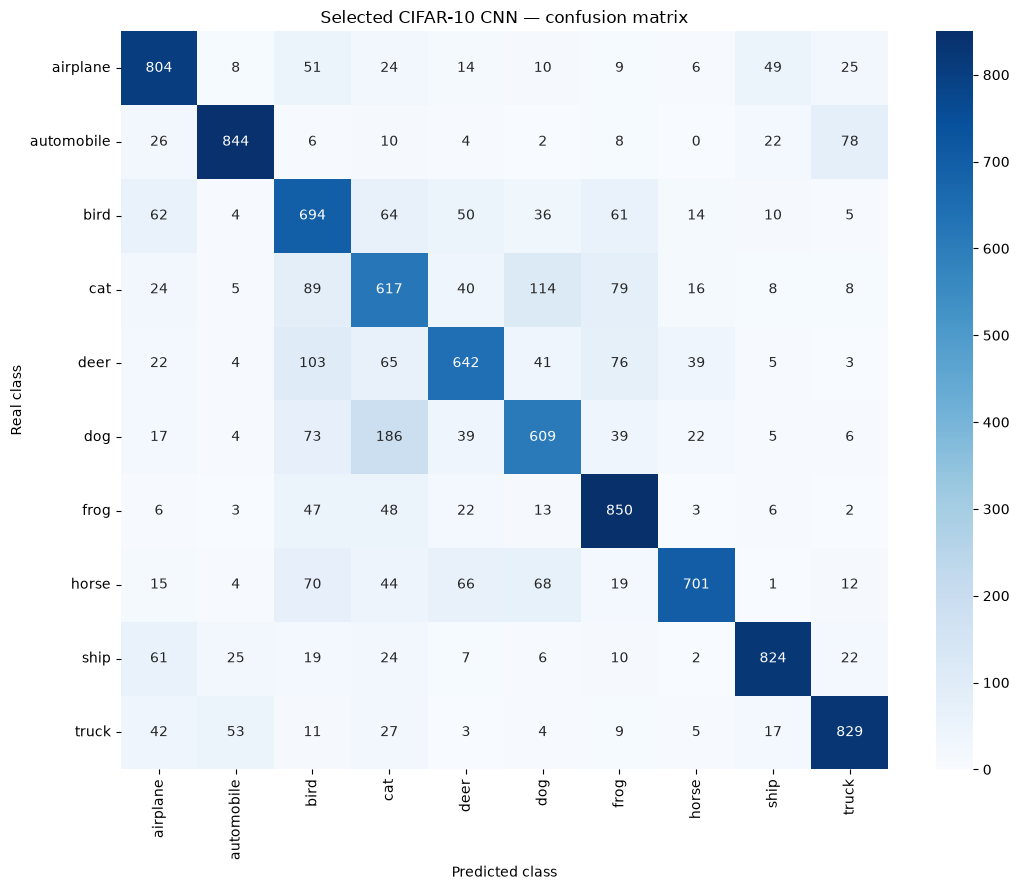

In [26]:
# Rows represent real classes; columns represent predicted classes.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(11, 9))

# Display the confusion matrix as a heatmap.
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)

plt.xlabel("Predicted class")
plt.ylabel("Real class")
plt.title("Selected CIFAR-10 CNN — confusion matrix")
plt.tight_layout()
plt.show()


Number of test errors: 2586


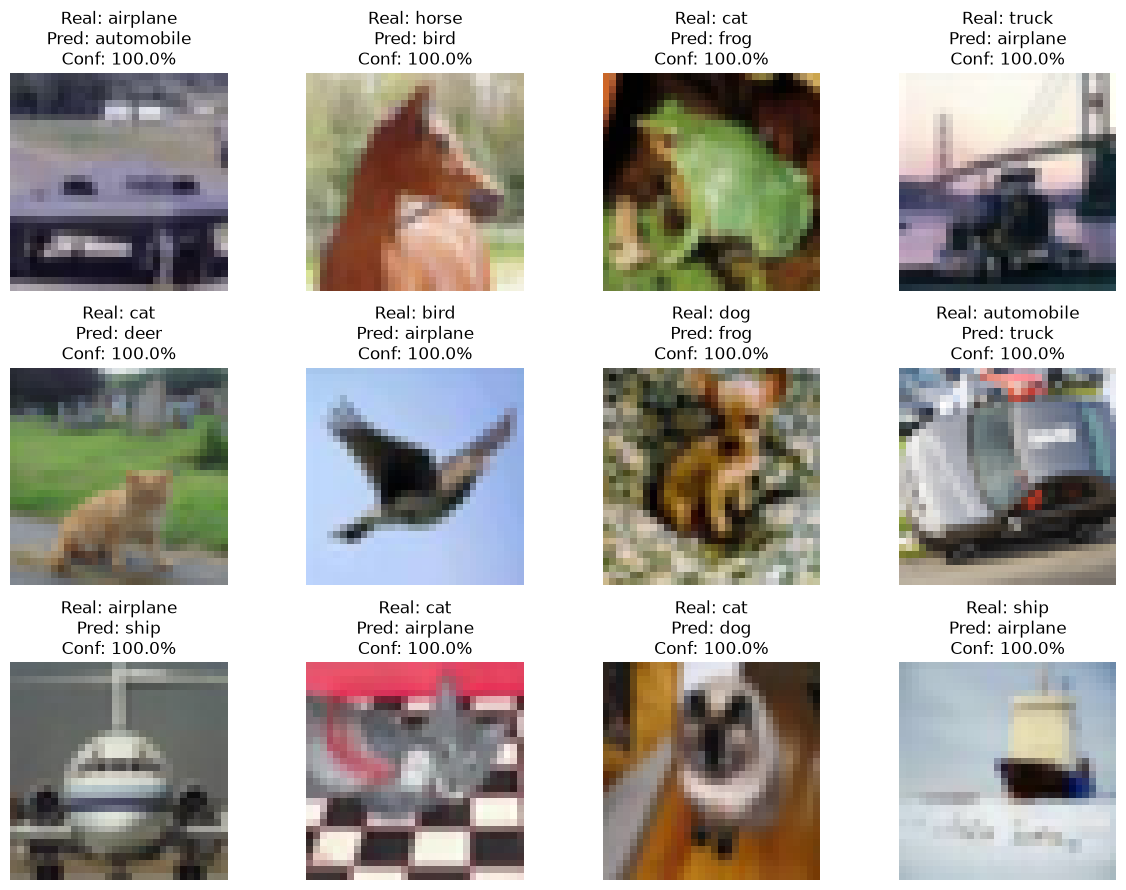

In [27]:
# Locate all incorrectly classified test images.
error_indices = np.where(y_pred != y_test)[0]

# Get the probability assigned to the model's selected class.
prediction_confidence = y_pred_proba[
    np.arange(len(y_pred)),
    y_pred,
]

# Sort errors from most confidently wrong to least confidently wrong.
error_confidence = prediction_confidence[error_indices]
order = np.argsort(error_confidence)[::-1]
confident_errors = error_indices[order]

print("Number of test errors:", len(error_indices))

# Display 12 confidently wrong examples.
plt.figure(figsize=(12, 9))

for position, index in enumerate(confident_errors[:12]):
    plt.subplot(3, 4, position + 1)
    plt.imshow(x_test[index])

    plt.title(
        f"Real: {class_names[y_test[index]]}\n"
        f"Pred: {class_names[y_pred[index]]}\n"
        f"Conf: {prediction_confidence[index]:.1%}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


## 8. Inspect one CNN feature map

This automatically finds convolution layers instead of relying on fragile hard-coded layer indexes.


In [28]:
# Find all convolution layers in the selected CNN.
conv_layers = [
    layer
    for layer in selected_cnn.layers
    if isinstance(layer, Conv2D)
]

# Show the available convolution layers and their output shapes.
for index, layer in enumerate(conv_layers):
    print(index, "-", layer.name, "-", layer.output.shape)


0 - conv2d - (None, 32, 32, 32)
1 - conv2d_1 - (None, 32, 32, 32)
2 - conv2d_2 - (None, 16, 16, 64)
3 - conv2d_3 - (None, 16, 16, 64)
4 - conv2d_4 - (None, 8, 8, 128)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Feature-map tensor shape: (1, 32, 32, 32)


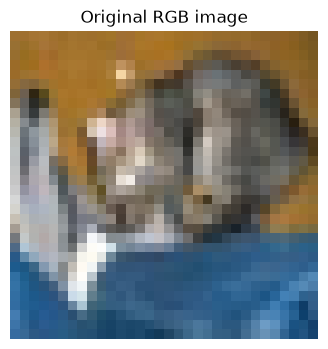

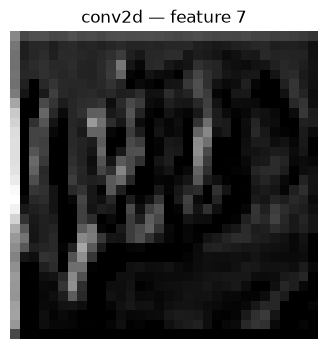

In [29]:
# Select a convolution layer, test image and output feature channel.
conv_layer_number = 0
image_number = 0
feature_number = 7

# Get the requested convolution layer.
selected_conv_layer = conv_layers[conv_layer_number]

# Build a small model that returns this intermediate layer.
feature_extractor = Model(
    inputs=selected_cnn.inputs,
    outputs=selected_conv_layer.output,
)

# Calculate feature maps for only one test image.
feature_maps = feature_extractor.predict(
    x_test[image_number:image_number + 1]
)

print("Feature-map tensor shape:", feature_maps.shape)

# Verify that the selected feature channel exists.
assert feature_number < feature_maps.shape[-1]

# Original RGB image.
plt.figure(figsize=(4, 4))
plt.imshow(x_test[image_number])
plt.title("Original RGB image")
plt.axis("off")
plt.show()

# One learned feature map.
plt.figure(figsize=(4, 4))
plt.imshow(feature_maps[0, :, :, feature_number], cmap="gray")
plt.title(f"{selected_conv_layer.name} — feature {feature_number}")
plt.axis("off")
plt.show()


## Main corrections from the uploaded CIFAR-10 file

The uploaded notebook contained only the initial setup, dataset loading, shape checks and one displayed image. This version keeps that starting logic but expands it into the same learning workflow as the Fashion-MNIST notebook.

Corrections:
- removed the empty first cell;
- removed the duplicate `cifar10.load_data()` call;
- removed imports not used in this workflow (`CategoricalCrossentropy`, `Accuracy`, `Reshape`);
- kept the PyTorch Keras backend;
- added a reproducible 40,000 / 10,000 / 10,000 train-validation-test structure;
- added assertions to protect against accidental data leakage;
- explicitly flattened CIFAR label arrays from `(N, 1)` to `(N,)`;
- added RGB-channel inspection;
- added Dense baseline, CNN baseline, overfitting checks and untouched-test evaluation;
- added optional augmentation + Dropout as a separate experiment;
- added classification report, confusion matrix, error inspection and feature-map inspection.

Important CIFAR-10 difference:
Fashion-MNIST input is `(28, 28)` and needs a grayscale channel added for CNN use.
CIFAR-10 input is already `(32, 32, 3)`, so no grayscale `Reshape` layer is required.
